In [3]:
import pandas as pd
df = pd.read_csv("C:/Users/skris/Downloads/AI_Healthcare_Heart_Disease/datasets/heart_disease_clean.csv")
print(df.shape)
print(df.head())
print(df.info())

(303, 15)
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   1     145.0  233.0    1        2    150.0      0      2.3   
1   67    1   4     160.0  286.0    0        2    108.0      1      1.5   
2   67    1   4     120.0  229.0    0        2    129.0      1      2.6   
3   37    1   3     130.0  250.0    0        0    187.0      0      3.5   
4   41    0   2     130.0  204.0    0        2    172.0      0      1.4   

   slope  ca  thal  target    disease_status  
0      3   0     6       0  No Heart Disease  
1      2   3     3       1     Heart Disease  
2      2   2     7       1     Heart Disease  
3      3   0     3       0  No Heart Disease  
4      1   0     3       0  No Heart Disease  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             303 non-null    int64  
 1   sex         

In [4]:
print(df["disease_status"].value_counts())
print(df["disease_status"].value_counts(normalize=True) * 100)

disease_status
No Heart Disease    164
Heart Disease       139
Name: count, dtype: int64
disease_status
No Heart Disease    54.125413
Heart Disease       45.874587
Name: proportion, dtype: float64


In [5]:
df["disease_status"] = df["disease_status"].map({
    "No Heart Disease": 0,
    "Heart Disease": 1
})
print(df["disease_status"].value_counts())

disease_status
0    164
1    139
Name: count, dtype: int64


In [6]:
X = df.drop(["disease_status", "target"], axis=1)
y = df["disease_status"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (303, 13)
y shape: (303,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (242, 13)
Scaled testing data shape: (61, 13)


In [9]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Heart Disease", "Heart Disease"]
))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61



Confusion Matrix:
[[27  6]
 [ 2 26]]


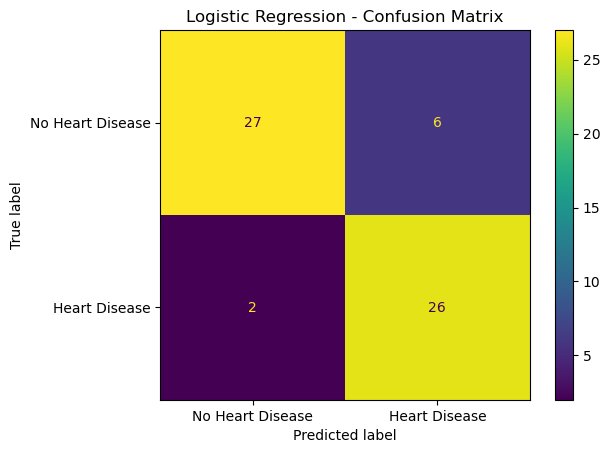

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN model trained successfully!")

KNN model trained successfully!


In [13]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("KNN Performance")
print("----------------")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

KNN Performance
----------------
Accuracy : 0.8852
Precision: 0.8
Recall   : 1.0
F1 Score : 0.8889


In [14]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully!")

SVM model trained successfully!


In [15]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Performance")
print("----------------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1 Score :", round(f1_svm, 4))

SVM Performance
----------------
Accuracy : 0.8525
Precision: 0.8065
Recall   : 0.8929
F1 Score : 0.8475


In [16]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree model trained successfully!")
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree model trained successfully!
Decision Tree Performance
-------------------------
Accuracy : 0.7377
Precision: 0.6765
Recall   : 0.8214
F1 Score : 0.7419


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Random Forest model trained successfully!
Random Forest Performance
-------------------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814


In [18]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes model trained successfully!")
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Performance")
print("-----------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

Naive Bayes model trained successfully!
Naive Bayes Performance
-----------------------
Accuracy : 0.8689
Precision: 0.7941
Recall   : 0.9643
F1 Score : 0.871


In [19]:
from sklearn.metrics import roc_auc_score

# Get probability predictions
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_nb = roc_auc_score(y_test, y_prob_nb)

print("ROC-AUC Scores")
print("----------------")
print("Logistic Regression:", round(auc_logistic, 4))
print("KNN                :", round(auc_knn, 4))
print("SVM                :", round(auc_svm, 4))
print("Random Forest      :", round(auc_rf, 4))
print("Naive Bayes        :", round(auc_nb, 4))

ROC-AUC Scores
----------------
Logistic Regression: 0.9513
KNN                : 0.9232
SVM                : 0.9437
Random Forest      : 0.9518
Naive Bayes        : 0.9524


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Logistic Regression Pipeline
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# KNN Pipeline
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# SVM Pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

# Decision Tree
dt_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=42))
])

# Random Forest
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GaussianNB())
])

In [21]:
models_cv = {
    "Logistic Regression": logistic_pipeline,
    "KNN": knn_pipeline,
    "SVM": svm_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Naive Bayes": nb_pipeline
}

cv_results = []

for name, model in models_cv.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="Mean Accuracy",
    ascending=False
)

print("Corrected 5-Fold Cross-Validation")
print("----------------------------------")

for _, row in cv_results_df.iterrows():
    print(
        f"{row['Model']}: "
        f"{row['Mean Accuracy']:.4f} "
        f"(± {row['Std']:.4f})"
    )

Corrected 5-Fold Cross-Validation
----------------------------------
Naive Bayes: 0.8546 (± 0.0403)
Random Forest: 0.8381 (± 0.0388)
SVM: 0.8381 (± 0.0390)
Logistic Regression: 0.8316 (± 0.0496)
KNN: 0.8218 (± 0.0262)
Decision Tree: 0.7655 (± 0.0469)


In [22]:
final_model = nb_pipeline

final_model.fit(X, y)

print("Final Naive Bayes model trained successfully!")

Final Naive Bayes model trained successfully!


In [23]:
sample_patient = X.iloc[[0]]

prediction = final_model.predict(sample_patient)
probability = final_model.predict_proba(sample_patient)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [0.30479655 0.69520345]


In [24]:
if prediction[0] == 1:
    print("Result: Heart Disease")
else:
    print("Result: No Heart Disease")

print("Disease Probability:", round(probability[0][1] * 100, 2), "%")

Result: Heart Disease
Disease Probability: 69.52 %


In [25]:
def predict_heart_disease():

    print("==============================================")
    print("       AI HEART DISEASE PREDICTION SYSTEM")
    print("==============================================")

    # Patient inputs
    age = float(input("Enter Age: "))
    sex = int(input("Enter Sex (1=Male, 0=Female): "))
    cp = int(input("Enter Chest Pain Type (1-4): "))
    trestbps = float(input("Enter Resting Blood Pressure: "))
    chol = float(input("Enter Cholesterol: "))
    fbs = int(input("Enter Fasting Blood Sugar (1=Yes, 0=No): "))
    restecg = int(input("Enter Resting ECG Result (0-2): "))
    thalach = float(input("Enter Maximum Heart Rate: "))
    exang = int(input("Enter Exercise Induced Angina (1=Yes, 0=No): "))
    oldpeak = float(input("Enter ST Depression (oldpeak): "))
    slope = int(input("Enter Slope (1-3): "))
    ca = int(input("Enter Number of Major Vessels (0-3): "))
    thal = int(input("Enter Thalassemia Type (3, 6, 7): "))

    # Create patient dataframe
    patient = pd.DataFrame([[
        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal
    ]], columns=X.columns)

    # Prediction
    prediction = final_model.predict(patient)

    # Probability
    probability = final_model.predict_proba(patient)[0][1] * 100

    # Risk category
    if probability < 30:
        risk_level = "Low Risk"
    elif probability <= 70:
        risk_level = "Moderate Risk"
    else:
        risk_level = "High Risk"

    # Prediction result
    if prediction[0] == 1:
        prediction_result = "Heart Disease"
    else:
        prediction_result = "No Heart Disease"

    # Display result
    print("\n==============================================")
    print("              PREDICTION RESULT")
    print("==============================================")

    print(f"Prediction        : {prediction_result}")
    print(f"Disease Probability: {probability:.2f}%")
    print(f"Risk Category     : {risk_level}")

    # ------------------------------------------
    # Predictive Insights
    # ------------------------------------------

    print("\n==============================================")
    print("             PREDICTIVE INSIGHTS")
    print("==============================================")

    insights = []

    if age >= 60:
        insights.append("• Patient belongs to an older age group.")

    if trestbps >= 140:
        insights.append("• Resting blood pressure is elevated.")

    if chol >= 240:
        insights.append("• Cholesterol level is elevated.")

    if thalach < 120:
        insights.append("• Maximum heart rate is relatively low.")

    if exang == 1:
        insights.append("• Exercise-induced angina is present.")

    if oldpeak > 2:
        insights.append("• ST depression (oldpeak) is elevated.")

    if cp >= 3:
        insights.append("• Chest pain category may be associated with increased model risk.")

    if ca >= 2:
        insights.append("• Major vessel involvement value is elevated.")

    if len(insights) == 0:
        insights.append("• No major feature-level indicators were identified using these project rules.")

    for insight in insights:
        print(insight)

    # ------------------------------------------
    # Decision Support
    # ------------------------------------------

    print("\n==============================================")
    print("             DECISION SUPPORT")
    print("==============================================")

    if risk_level == "High Risk":
        print("• The model indicates a high predicted risk.")
        print("• Further clinical evaluation is recommended.")
    elif risk_level == "Moderate Risk":
        print("• The model indicates a moderate predicted risk.")
        print("• Further assessment may be appropriate.")
    else:
        print("• The model indicates a low predicted risk.")
        print("• Continue appropriate health monitoring.")

    print("\n⚠ IMPORTANT:")
    print("This is an AI-based prediction and decision-support tool.")
    print("It is NOT a medical diagnosis.")
    print("Clinical decisions should be made by qualified healthcare professionals.")

    print("==============================================")

In [26]:
predict_heart_disease()

       AI HEART DISEASE PREDICTION SYSTEM


Enter Age:  75
Enter Sex (1=Male, 0=Female):  1
Enter Chest Pain Type (1-4):  2
Enter Resting Blood Pressure:  153
Enter Cholesterol:  200
Enter Fasting Blood Sugar (1=Yes, 0=No):  1
Enter Resting ECG Result (0-2):  1
Enter Maximum Heart Rate:  97
Enter Exercise Induced Angina (1=Yes, 0=No):  1
Enter ST Depression (oldpeak):  0.85
Enter Slope (1-3):  2
Enter Number of Major Vessels (0-3):  2
Enter Thalassemia Type (3, 6, 7):  6



              PREDICTION RESULT
Prediction        : Heart Disease
Disease Probability: 99.99%
Risk Category     : High Risk

             PREDICTIVE INSIGHTS
• Patient belongs to an older age group.
• Resting blood pressure is elevated.
• Maximum heart rate is relatively low.
• Exercise-induced angina is present.
• Major vessel involvement value is elevated.

             DECISION SUPPORT
• The model indicates a high predicted risk.
• Further clinical evaluation is recommended.

⚠ IMPORTANT:
This is an AI-based prediction and decision-support tool.
It is NOT a medical diagnosis.
Clinical decisions should be made by qualified healthcare professionals.


Naive Bayes Confusion Matrix:
[[26  7]
 [ 1 27]]


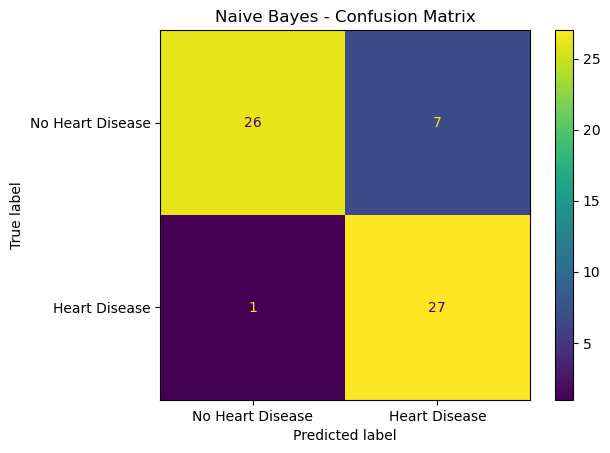

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Naive Bayes Confusion Matrix:")
print(cm_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

Naive Bayes ROC-AUC: 0.9524


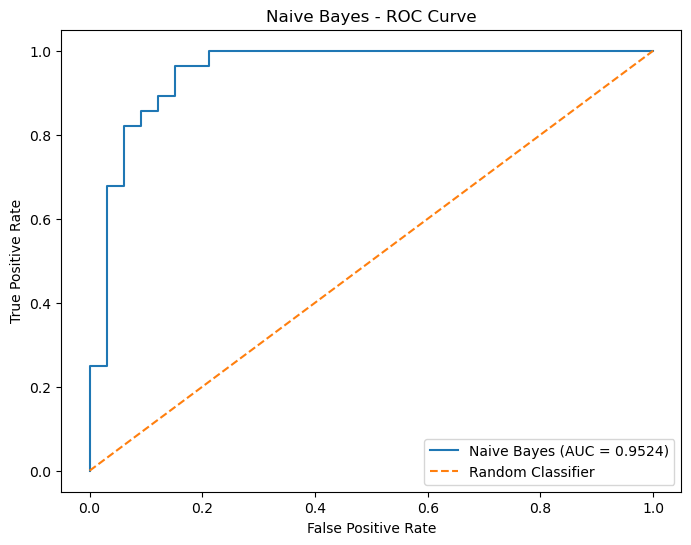

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of Heart Disease
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)

# Calculate AUC
auc_nb = roc_auc_score(y_test, y_prob_nb)

print("Naive Bayes ROC-AUC:", round(auc_nb, 4))

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Naive Bayes (AUC = {auc_nb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes - ROC Curve")
plt.legend()
plt.show()

In [29]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm = permutation_importance(
    nb_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

     Feature  Importance
11        ca    0.121311
9    oldpeak    0.065574
2         cp    0.042623
8      exang    0.026230
12      thal    0.019672
7    thalach    0.013115
1        sex    0.013115
0        age    0.009836
6    restecg   -0.003279
3   trestbps   -0.004918
5        fbs   -0.004918
10     slope   -0.009836
4       chol   -0.013115


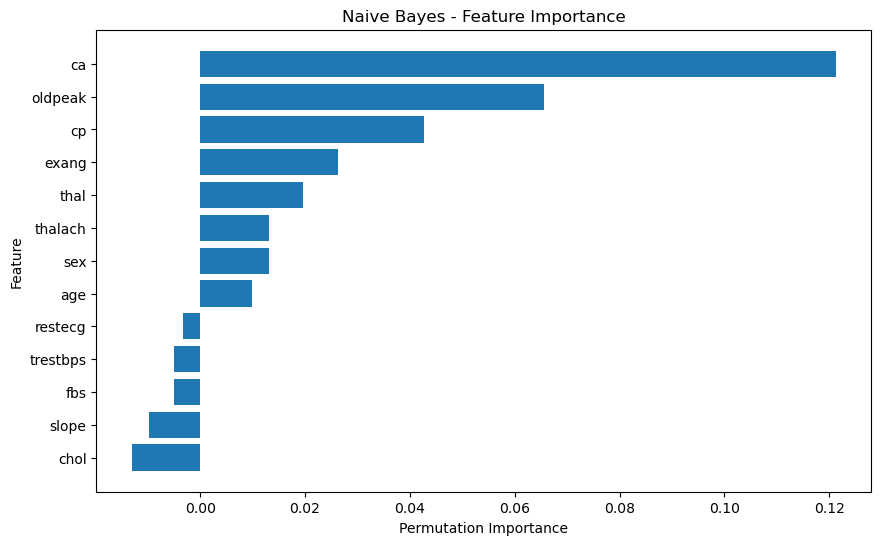

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Naive Bayes - Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [31]:
import joblib

joblib.dump(nb_pipeline, "heart_disease_naive_bayes_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [70]:
import pandas as pd
import joblib

# Load saved pipeline
pipeline = joblib.load("C:/Users/skris/heart_disease_naive_bayes_model.pkl")

# Load cleaned dataset

print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'disease_status',
       'prediction', 'prediction_status'],
      dtype='object')


In [72]:
X = df.drop(
    columns=["target", "prediction", "prediction_status"],
    errors="ignore"
)

In [76]:
import pandas as pd
import joblib

# Load saved pipeline
pipeline = joblib.load("C:/Users/skris/heart_disease_naive_bayes_model.pkl")

# Load cleaned dataset


# ML features used for prediction
features = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

# Create input data for ML model
X = df[features]

# Generate predictions
predictions = pipeline.predict(X)

# Add predictions to original dataset
df["prediction"] = predictions

# Convert prediction to readable status
df["prediction_status"] = df["prediction"].map({
    0: "No Disease",
    1: "Disease"
})

# Save prediction dataset for Power BI
df.to_csv("heart_disease_predictions.csv", index=False)

print("Prediction completed successfully!")
print(df[["age", "disease_status", "prediction", "prediction_status"]].head())

Prediction completed successfully!
   age  disease_status  prediction prediction_status
0   63               0           1           Disease
1   67               1           1           Disease
2   67               1           1           Disease
3   37               0           1           Disease
4   41               0           0        No Disease


In [1]:
import joblib

model = joblib.load(
    "C:/Users/skris/heart_disease_naive_bayes_model.pkl"
)

print("Model classes:")
print(model.classes_)

print("Number of classes:")
print(len(model.classes_))

Model classes:
[0 1]
Number of classes:
2
